In [172]:
import csv
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import tensorflow as tf


class FrameCSVSequence(tf.keras.utils.Sequence):
    """
    Keras Sequence that reads (filename,left,right) from a CSV and builds
    temporal windows of length seq_len (default 128) ending at the current frame.
    Pads missing past frames with zeros on the left.

    Output:
      X: (B, seq_len, H, W, 3) float32 in [0,1]
      y: (B, 3) one-hot for [Left, None, Right] using:
           none=1 if (left,right) is (0,0) or (1,1)
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        batch_size=8,
        seq_len=128,
        max_none_per_epoch=0,   # 0 means "no limit"
        mask_boxes=None,        # list of (xmin,ymin,xmax,ymax) to black out
        shuffle=True,
        image_size=(224, 224),
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.batch_size = int(batch_size)
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.shuffle = bool(shuffle)
        self.image_size = tuple(image_size)

        # Load CSV rows
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Sort by filename to preserve temporal order in the underlying timeline
        rows = sorted(rows, key=lambda r: r["filename"])

        self.filenames = [r["filename"] for r in rows]
        self.lefts = np.array([int(r["left"]) for r in rows], dtype=np.int32)
        self.rights = np.array([int(r["right"]) for r in rows], dtype=np.int32)

        # Define label indices for current frame
        # 0=Left, 1=None, 2=Right
        self.y_idx = np.zeros(len(rows), dtype=np.int32)
        for i in range(len(rows)):
            l = self.lefts[i]
            r = self.rights[i]
            none = 1 if (l == r) else 0
            if l == 1 and r == 0:
                self.y_idx[i] = 0
            elif none == 1:
                self.y_idx[i] = 1
            else:
                self.y_idx[i] = 2

        # Build initial sampling indices for the epoch
        self._build_epoch_indices()
        self.on_epoch_end()

    def _build_epoch_indices(self):
        all_indices = list(range(len(self.filenames)))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        # max_none_per_epoch convention:
        #  -1 => no limit (include all None)
        #   0 => exclude None
        #  >0 => include at most this many None
        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            random.shuffle(none_indices)
            chosen_none = none_indices[: self.max_none_per_epoch]

        self.epoch_indices = non_none_indices + chosen_none
        random.shuffle(self.epoch_indices)


    def __len__(self):
        return math.ceil(len(self.epoch_indices) / self.batch_size)

    def on_epoch_end(self):
        # Rebuild indices each epoch to re-sample None frames if limited
        self._build_epoch_indices()

        if self.shuffle:
            random.shuffle(self.epoch_indices)

    def _load_frame(self, index):
        """
        Load a single frame by index, apply masks, resize, normalize to [0,1].
        Returns float32 array (H,W,3).
        """
        img_path = self.frames_dir / self.filenames[index]

        with Image.open(img_path) as im:
            im = im.convert("RGB")

            # Apply masking if provided
            if self.mask_boxes:
                im_arr = np.array(im, dtype=np.uint8)
                for (xmin, ymin, xmax, ymax) in self.mask_boxes:
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(im_arr.shape[1], xmax)
                    ymax = min(im_arr.shape[0], ymax)
                    if xmax > xmin and ymax > ymin:
                        im_arr[ymin:ymax, xmin:xmax, :] = 0
                im = Image.fromarray(im_arr)

            # Resize
            im = im.resize((self.image_size[1], self.image_size[0]))  # PIL uses (W,H)

            # Normalize /255 -> float32
            x = np.asarray(im, dtype=np.float32) / 255.0

        return x

    def __getitem__(self, batch_idx):
        start = batch_idx * self.batch_size
        end = min(start + self.batch_size, len(self.epoch_indices))
        batch_indices = self.epoch_indices[start:end]

        B = len(batch_indices)
        H, W = self.image_size
        T = self.seq_len

        X = np.zeros((B, T, H, W, 3), dtype=np.float32)
        y = np.zeros((B, 3), dtype=np.float32)

        for b, cur_idx in enumerate(batch_indices):
            # Build sequence indices: [cur_idx-(T-1), ..., cur_idx]
            seq_start = cur_idx - (T - 1)

            for t in range(T):
                src_idx = seq_start + t
                if src_idx < 0:
                    # left pad with zeros
                    continue
                # If you ever split videos into multiple folders, you may want
                # to guard against crossing a boundary here.
                X[b, t] = self._load_frame(src_idx)

            # Target is label of CURRENT frame (cur_idx)
            cls = int(self.y_idx[cur_idx])  # 0,1,2
            y[b, cls] = 1.0

        return X, y
    
import csv
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import tensorflow as tf


class FrameCSVSequence(tf.keras.utils.Sequence):
    """
    Keras Sequence that reads (filename,left,right) from a CSV and builds
    temporal windows of length seq_len ending at the current frame.
    Pads missing past frames with zeros on the left.

    Output:
      X: (B, seq_len, H, W, 3) float32 in [0,1]
      y: (B,) int32 sparse labels: 0=Left, 1=None, 2=Right
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        batch_size=8,
        seq_len=128,
        max_none_per_epoch=0,   # 0 means "exclude None" in your current logic
        mask_boxes=None,
        shuffle=True,
        image_size=(224, 224),
        return_y_shape="flat",  # "flat" => (B,), "col" => (B,1)
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.batch_size = int(batch_size)
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.shuffle = bool(shuffle)
        self.image_size = tuple(image_size)
        self.return_y_shape = return_y_shape

        # Load CSV rows
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Sort by filename to preserve temporal order in the underlying timeline
        rows = sorted(rows, key=lambda r: r["filename"])

        self.filenames = [r["filename"] for r in rows]
        self.lefts = np.array([int(r["left"]) for r in rows], dtype=np.int32)
        self.rights = np.array([int(r["right"]) for r in rows], dtype=np.int32)

        # Define label indices: 0=None, 1=Left, 2=Right
        self.y_idx = np.zeros(len(rows), dtype=np.int32)

        for i in range(len(rows)):
            l = self.lefts[i]
            r = self.rights[i]

            if l == r:
                self.y_idx[i] = 0      # None
            elif l == 1 and r == 0:
                self.y_idx[i] = 1      # Left
            else:
                self.y_idx[i] = 2      # Right


        # Build initial sampling indices for the epoch
        self._build_epoch_indices()
        self.on_epoch_end()

    def _build_epoch_indices(self):
        all_indices = list(range(len(self.filenames)))

        none_indices = [i for i in all_indices if self.y_idx[i] == 1]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 1]

        # max_none_per_epoch convention in your code:
        #  -1 => include all None
        #   0 => exclude None
        #  >0 => include at most this many None
        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            random.shuffle(none_indices)
            chosen_none = none_indices[: self.max_none_per_epoch]

        self.epoch_indices = non_none_indices + chosen_none
        random.shuffle(self.epoch_indices)

    def __len__(self):
        return math.ceil(len(self.epoch_indices) / self.batch_size)

    def on_epoch_end(self):
        self._build_epoch_indices()
        if self.shuffle:
            random.shuffle(self.epoch_indices)

    def _load_frame(self, index):
        img_path = self.frames_dir / self.filenames[index]

        with Image.open(img_path) as im:
            im = im.convert("RGB")

            # Apply masking if provided
            if self.mask_boxes:
                im_arr = np.array(im, dtype=np.uint8)
                for (xmin, ymin, xmax, ymax) in self.mask_boxes:
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(im_arr.shape[1], xmax)
                    ymax = min(im_arr.shape[0], ymax)
                    if xmax > xmin and ymax > ymin:
                        im_arr[ymin:ymax, xmin:xmax, :] = 0
                im = Image.fromarray(im_arr)

            # Resize (PIL uses (W,H))
            im = im.resize((self.image_size[1], self.image_size[0]))

            # Normalize to [0,1]
            x = np.asarray(im, dtype=np.float32) / 255.0

        return x

    def __getitem__(self, batch_idx):
        start = batch_idx * self.batch_size
        end = min(start + self.batch_size, len(self.epoch_indices))
        batch_indices = self.epoch_indices[start:end]

        B = len(batch_indices)
        H, W = self.image_size
        T = self.seq_len

        X = np.zeros((B, T, H, W, 3), dtype=np.float32)
        y = np.zeros((B,), dtype=np.int32)  # sparse labels

        for b, cur_idx in enumerate(batch_indices):
            cls = int(self.y_idx[cur_idx])   # 0,1,2
            y[b] = cls

            # If label is Right (2), keep the whole sequence as zeros
            if cls == 2:
                continue

            # Otherwise, build the normal sequence
            seq_start = cur_idx - (T - 1)
            for t in range(T):
                src_idx = seq_start + t
                if src_idx < 0:
                    continue
                X[b, t] = self._load_frame(src_idx)

        return X, y





In [181]:
import csv
import math
import random
from pathlib import Path

import numpy as np
from PIL import Image
import tensorflow as tf


class FrameCSVSequence(tf.keras.utils.Sequence):
    """
    Keras Sequence that reads (filename,left,right) from a CSV and builds
    temporal windows of length seq_len ending at the current frame.
    Pads missing past frames with zeros on the left.

    Output:
      X: (B, seq_len, H, W, 3) float32 in [0,1]
      y: (B,) int32 sparse labels: 0=None, 1=Left, 2=Right
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        batch_size=8,
        seq_len=128,
        max_none_per_epoch=0,   # -1 include all None, 0 exclude None, >0 cap None
        mask_boxes=None,        # list of (xmin,ymin,xmax,ymax) to black out
        shuffle=True,
        image_size=(224, 224),
        return_y_shape="flat",  # "flat" => (B,), "col" => (B,1)
    ):
        self.csv_path = Path(csv_path)
        self.frames_dir = Path(frames_dir)
        self.batch_size = int(batch_size)
        self.seq_len = int(seq_len)
        self.max_none_per_epoch = int(max_none_per_epoch)
        self.mask_boxes = mask_boxes or []
        self.shuffle = bool(shuffle)
        self.image_size = tuple(image_size)
        self.return_y_shape = return_y_shape

        # Load CSV rows
        with open(self.csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Sort by filename to preserve temporal order in the underlying timeline
        rows = sorted(rows, key=lambda r: r["filename"])

        self.filenames = [r["filename"] for r in rows]
        self.lefts = np.array([int(r["left"]) for r in rows], dtype=np.int32)
        self.rights = np.array([int(r["right"]) for r in rows], dtype=np.int32)

        # Define label indices: 0=None, 1=Left, 2=Right
        self.y_idx = np.zeros(len(rows), dtype=np.int32)
        for i in range(len(rows)):
            l = self.lefts[i]
            r = self.rights[i]

            if l == r:
                self.y_idx[i] = 0      # None
            elif l == 1 and r == 0:
                self.y_idx[i] = 1      # Left
            else:
                self.y_idx[i] = 2      # Right

        # Build initial sampling indices for the epoch
        self._build_epoch_indices()
        self.on_epoch_end()

    def _build_epoch_indices(self):
        all_indices = list(range(len(self.filenames)))

        none_indices = [i for i in all_indices if self.y_idx[i] == 0]
        non_none_indices = [i for i in all_indices if self.y_idx[i] != 0]

        # max_none_per_epoch convention:
        #  -1 => include all None
        #   0 => exclude None
        #  >0 => include at most this many None
        if self.max_none_per_epoch == -1:
            chosen_none = none_indices
        elif self.max_none_per_epoch == 0:
            chosen_none = []
        else:
            random.shuffle(none_indices)
            chosen_none = none_indices[: self.max_none_per_epoch]

        self.epoch_indices = non_none_indices + chosen_none
        random.shuffle(self.epoch_indices)

    def __len__(self):
        return math.ceil(len(self.epoch_indices) / self.batch_size)

    def on_epoch_end(self):
        # Rebuild indices each epoch to re-sample None frames if limited
        self._build_epoch_indices()
        if self.shuffle:
            random.shuffle(self.epoch_indices)

    def _load_frame(self, index):
        """
        Load a single frame by index, apply masks, resize, normalize to [0,1].
        Returns float32 array (H,W,3).
        """
        img_path = self.frames_dir / self.filenames[index]

        with Image.open(img_path) as im:
            im = im.convert("RGB")

            # Apply masking if provided
            if self.mask_boxes:
                im_arr = np.array(im, dtype=np.uint8)
                for (xmin, ymin, xmax, ymax) in self.mask_boxes:
                    xmin = max(0, xmin)
                    ymin = max(0, ymin)
                    xmax = min(im_arr.shape[1], xmax)
                    ymax = min(im_arr.shape[0], ymax)
                    if xmax > xmin and ymax > ymin:
                        im_arr[ymin:ymax, xmin:xmax, :] = 0
                im = Image.fromarray(im_arr)

            # Resize (PIL uses (W,H))
            im = im.resize((self.image_size[1], self.image_size[0]))

            # Normalize to [0,1]
            x = np.asarray(im, dtype=np.float32) / 255.0

        return x

    def __getitem__(self, batch_idx):
        start = batch_idx * self.batch_size
        end = min(start + self.batch_size, len(self.epoch_indices))
        batch_indices = self.epoch_indices[start:end]

        B = len(batch_indices)
        H, W = self.image_size
        T = self.seq_len

        X = np.zeros((B, T, H, W, 3), dtype=np.float32)
        y = np.zeros((B,), dtype=np.int32)  # sparse labels

        for b, cur_idx in enumerate(batch_indices):
            cls = int(self.y_idx[cur_idx])   # 0=None, 1=Left, 2=Right
            y[b] = cls

            # If label is Right (2), keep the whole sequence as zeros
            # (per your earlier request)
            if cls == 2:
                continue

            # Otherwise, build the normal sequence
            seq_start = cur_idx - (T - 1)
            for t in range(T):
                src_idx = seq_start + t
                if src_idx < 0:
                    # left pad with zeros
                    continue
                X[b, t] = self._load_frame(src_idx)

        if self.return_y_shape == "col":
            y = y.reshape(-1, 1)

        return X, y


In [182]:
train_csv_path = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224_controls_extracted.csv"
train_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224"
train_csv_path2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_controls_extracted.csv"
train_frames_dir2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224"
val_csv_path = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224_controls_extracted.csv"
val_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224"
image_size = (224, 224)
batch_size = 1
seq_len = 1

mask_boxes = [
    (2, 103, 58, 147),      # example left HUD region
    (165, 103, 221, 147),   # example right HUD region
]
mask_boxes = None
train_gen = FrameCSVSequence(
    csv_path=train_csv_path,
    frames_dir=train_frames_dir,
    batch_size=batch_size,
    seq_len=seq_len,
    max_none_per_epoch=0,
    mask_boxes=mask_boxes,
    shuffle=True,
    image_size=image_size
)

train_gen2 = FrameCSVSequence(
    csv_path=train_csv_path,
    frames_dir=train_frames_dir,
    batch_size=batch_size,
    seq_len=seq_len,
    max_none_per_epoch=0,
    mask_boxes=mask_boxes,
    shuffle=True,
    image_size=image_size
)

val_gen = FrameCSVSequence(
    csv_path=train_csv_path,
    frames_dir=train_frames_dir,
    batch_size=batch_size,
    seq_len=seq_len,
    max_none_per_epoch=0,
    mask_boxes=mask_boxes,
    shuffle=True,
    image_size=image_size
)

In [187]:
x, y = train_gen.__getitem__(80)  # test load first batch

In [147]:
np.unique(x)

array([0.], dtype=float32)

In [188]:
y

array([1])

In [178]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np


def visualize_random_sequence(
    sequence,
    max_frames_to_show=32,
    max_cols=8,
    figsize_per_cell=(2.5, 2.5),
    cls_map=None,
):
    """
    Randomly samples one sequence from a FrameCSVSequence and visualizes
    frames in a grid with up to max_cols columns.

    Supports BOTH:
      - one-hot labels: y shape (B, C)
      - sparse labels: y shape (B,) or (B,1)

    The class label corresponds to the LAST frame in the sequence.
    """
    if cls_map is None:
        cls_map = {0: "L", 1: "N", 2: "R"}

    # Pick random batch and random sample within batch
    batch_idx = random.randint(0, len(sequence) - 1)
    X, y = sequence[batch_idx]
    sample_idx = random.randint(0, X.shape[0] - 1)

    frames = X[sample_idx]  # (T, H, W, 3)
    T = frames.shape[0]

    # --- label extraction (one-hot or sparse) ---
    y_s = y[sample_idx]

    # If one-hot: (C,)
    if isinstance(y_s, np.ndarray) and y_s.ndim == 1 and y_s.size > 1:
        label_idx = int(np.argmax(y_s))

    # If sparse: scalar, (1,), or python int/np.int32/np.int64
    else:
        # handles y_s being shape (1,) or scalar
        label_idx = int(np.asarray(y_s).reshape(-1)[0])

    label_str = cls_map.get(label_idx, str(label_idx))

    # Select frames to show
    if T <= max_frames_to_show:
        idxs = list(range(T))
    else:
        idxs = np.linspace(0, T - 1, max_frames_to_show, dtype=int)

    n_imgs = len(idxs)
    cols = min(max_cols, n_imgs)
    rows = math.ceil(n_imgs / cols)

    fig_w = cols * figsize_per_cell[0]
    fig_h = rows * figsize_per_cell[1]

    plt.figure(figsize=(fig_w, fig_h))

    for i, t in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frames[t])
        plt.axis("off")

        # Mark the last frame (the supervised one)
        if t == T - 1:
            title = f"t={t}  ← {label_str}"
            plt.title(title, fontsize=9, color="red")
        else:
            plt.title(f"t={t}", fontsize=8)

    plt.suptitle(
        f"Random temporal sample | batch={batch_idx}, sample={sample_idx} | "
        f"Target = {label_str}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


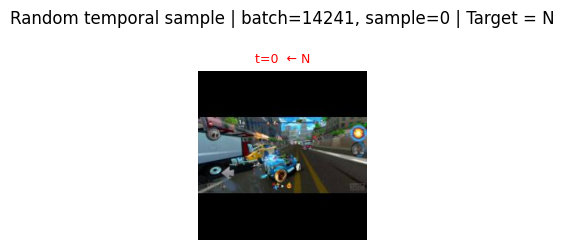

In [191]:
visualize_random_sequence(train_gen, max_frames_to_show=5)

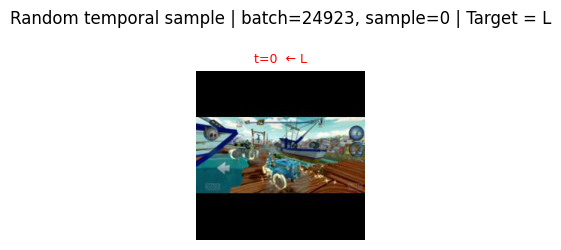

In [150]:
visualize_random_sequence(val_gen, max_frames_to_show=5)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model


def build_cnn_lstm(
    timesteps=128,
    frame_size=(224, 224, 3),
    num_classes=3,
    embed_dim=256,
    lstm_units=256,
    dropout=0.3,
):
    """
    Input:  (B, T, H, W, C)
    Output: (B, num_classes) logits
    """

    seq_in = layers.Input(shape=(timesteps, *frame_size), name="frames_seq")

    # --- Per-frame CNN encoder (shared across time) ---
    # Keep it lightweight and end with a vector embedding

    x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(seq_in)
    x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(64, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(128, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.Conv2D(128, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(256, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.Conv2D(256, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)
    
    x = layers.TimeDistributed(layers.Conv2D(256, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.Conv2D(256, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)
    x = layers.TimeDistributed(layers.Flatten())(x)  # (B, T, 256)

    # Optional projection to embed_dim
    x = layers.TimeDistributed(layers.Dense(embed_dim, activation="relu"))(x)  # (B, T, embed_dim)

    # --- Temporal model ---
    x = layers.LSTM(lstm_units, return_sequences=False)(x)  # (B, lstm_units)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    logits = layers.Dense(num_classes, name="action_logits")(x)

    model = Model(seq_in, logits, name="CNN_LSTM_128")
    return model

model = build_cnn_lstm(
    timesteps=seq_len,
    frame_size=(224, 224, 3),
    num_classes=3,   # Left, None, Right
)

model.summary()




Model: "CNN_LSTM_128"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 frames_seq (InputLayer)     [(None, 1, 224, 224, 3)]  0         
                                                                 
 time_distributed_26 (TimeDi  (None, 1, 224, 224, 32)  896       
 stributed)                                                      
                                                                 
 time_distributed_27 (TimeDi  (None, 1, 224, 224, 32)  9248      
 stributed)                                                      
                                                                 
 time_distributed_28 (TimeDi  (None, 1, 112, 112, 32)  0         
 stributed)                                                      
                                                                 
 time_distributed_29 (TimeDi  (None, 1, 112, 112, 64)  18496     
 stributed)                                           

In [151]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras import models as M
from tensorflow.keras import regularizers as R


def build_cnn_lstm_for_frames(
    seq_len=128,
    image_size=(224, 224),
    n_classes=3,
    lstm_units=256,
    dropout=0.2,
    l2=1e-4,
    bidirectional=False,
):
    H, W = image_size
    x_in = L.Input(shape=(seq_len, H, W, 3), name="frames")  # (B,T,H,W,3)

    def frame_cnn():
        return M.Sequential(
            [
                L.Conv2D(32, 3, padding="same", kernel_regularizer=R.l2(l2)),
                L.Conv2D(32, 3, padding="same", kernel_regularizer=R.l2(l2)),
                L.BatchNormalization(),
                L.ReLU(),
                L.MaxPool2D(),  # /2

                L.Conv2D(64, 3, padding="same", kernel_regularizer=R.l2(l2)),
                L.Conv2D(64, 3, padding="same", kernel_regularizer=R.l2(l2)),
                L.BatchNormalization(),
                L.ReLU(),
                L.MaxPool2D(),  # /4

                L.Conv2D(128, 3, padding="same", kernel_regularizer=R.l2(l2)),
                L.BatchNormalization(),
                L.ReLU(),
                L.Conv2D(128, 3, padding="same", kernel_regularizer=R.l2(l2)),
                L.BatchNormalization(),
                L.ReLU(),

                # Important: Flatten after convs gives a very large vector
                # Prefer GAP for stability unless you have a strong reason to Flatten
                L.GlobalAveragePooling2D(),

                L.Dense(512, activation="relu", kernel_regularizer=R.l2(l2)),
                L.Dropout(dropout),
                L.Dense(256, activation="relu", kernel_regularizer=R.l2(l2)),
            ],
            name="frame_cnn",
        )

    # Per-frame feature extraction
    seq_feats = L.TimeDistributed(frame_cnn(), name="td_frame_cnn")(x_in)  # (B,T,256)

    # Temporal modeling
    if bidirectional:
        seq_out = L.Bidirectional(
            L.LSTM(lstm_units, return_sequences=False, dropout=dropout),
            name="bilstm",
        )(seq_feats)
    else:
        seq_out = L.LSTM(
            lstm_units, return_sequences=False, dropout=dropout, name="lstm"
        )(seq_feats)

    seq_out = L.Dense(128, activation="relu", kernel_regularizer=R.l2(l2))(seq_out)
    seq_out = L.Dropout(dropout)(seq_out)

    # Classifier: 3-way
    probs = L.Dense(n_classes, activation="softmax", name="probs")(seq_out)

    model = M.Model(inputs=x_in, outputs=probs, name="cnn_lstm_3class")
    return model

model = build_cnn_lstm_for_frames(
    seq_len=seq_len,
    image_size=(224, 224),
    n_classes=3,
    lstm_units=256,
    dropout=0.2,
    l2=1e-4,
    bidirectional=False,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
model.summary()

Model: "cnn_lstm_3class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 frames (InputLayer)         [(None, 1, 224, 224, 3)]  0         
                                                                 
 td_frame_cnn (TimeDistribut  (None, 1, 256)           485792    
 ed)                                                             
                                                                 
 lstm (LSTM)                 (None, 256)               525312    
                                                                 
 dense_20 (Dense)            (None, 128)               32896     
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                                                 
 probs (Dense)               (None, 3)                 387       
                                                   

Model: "cnn_lstm_3class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 frames (InputLayer)         [(None, 1, 224, 224, 3)]  0         
                                                                 
 td_frame_cnn (TimeDistribut  (None, 1, 256)           485792    
 ed)                                                             
                                                                 
 lstm (LSTM)                 (None, 256)               525312    
                                                                 
 dense_14 (Dense)            (None, 128)               32896     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 probs (Dense)               (None, 3)                 387       
                                                   

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, Model


def build_cnn_lstm_with_attention(
    timesteps,
    frame_size=(224, 224, 3),
    num_classes=3,
    embed_dim=256,
    lstm_units=256,
    dropout=0.3,
):
    """
    CNN + LSTM + Temporal Attention
    Input : (B, T, H, W, 3)
    Output: (B, num_classes) logits
    """

    seq_in = layers.Input(shape=(timesteps, *frame_size), name="frames_seq")

    # ---- Per-frame CNN encoder (shared across time) ----
    x = layers.TimeDistributed(layers.Conv2D(32, 3, padding="same", activation="relu"))(seq_in)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(64, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(128, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.MaxPool2D())(x)

    x = layers.TimeDistributed(layers.Conv2D(256, 3, padding="same", activation="relu"))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)  # (B, T, 256)

    # Optional projection
    x = layers.TimeDistributed(layers.Dense(embed_dim, activation="relu"))(x)  # (B, T, embed_dim)

    # ---- LSTM (keep sequence!) ----
    x = layers.LSTM(lstm_units, return_sequences=True)(x)  # (B, T, lstm_units)

    # ---- Temporal Attention ----
    # Attention scores over time
    attn_scores = layers.Dense(1, name="attn_scores")(x)         # (B, T, 1)
    attn_weights = layers.Softmax(axis=1, name="attn_weights")(attn_scores)

    # Weighted sum of LSTM outputs
    context = layers.Multiply()([x, attn_weights])               # (B, T, lstm_units)
    context = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1),
                            name="attn_context")(context)        # (B, lstm_units)

    # ---- Classification head ----
    context = layers.Dropout(dropout)(context)
    context = layers.Dense(256, activation="relu")(context)
    logits = layers.Dense(num_classes, name="action_logits")(context)

    model = Model(seq_in, logits, name="CNN_LSTM_Attention")
    return model

model = build_cnn_lstm_with_attention(
    timesteps=seq_len,
    frame_size=(224, 224, 3),
    num_classes=3,   # Left, None, Right
)

model.summary()



Model: "CNN_LSTM_Attention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 frames_seq (InputLayer)        [(None, 128, 224, 2  0           []                               
                                24, 3)]                                                           
                                                                                                  
 time_distributed (TimeDistribu  (None, 128, 224, 22  896        ['frames_seq[0][0]']             
 ted)                           4, 32)                                                            
                                                                                                  
 time_distributed_1 (TimeDistri  (None, 128, 112, 11  0          ['time_distributed[0][0]']       
 buted)                         2, 32)                                           

In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="acc")]
)


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    ],
)


In [152]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [195]:
model.fit(train_gen, validation_data=train_gen,epochs=10)


Epoch 1/10
31215/31215 [==============================] - 619s 20ms/step - loss: 0.0031 - accuracy: 0.9999 - val_loss: 8.6078 - val_accuracy: 0.5160
Epoch 2/10
 7127/31215 [=====>........................] - ETA: 5:01 - loss: 7.5953e-04 - accuracy: 1.0000

KeyboardInterrupt: 

In [194]:
model.fit(train_gen2, validation_data=val_gen,epochs=1)

31215/31215 [==============================] - 554s 18ms/step - loss: 0.0023 - accuracy: 0.9999 - val_loss: 11.6808 - val_accuracy: 0.4840


In [18]:
model.fit(train_gen, validation_data=val_gen,epochs=1)

976/976 [==============================] - 66s 68ms/step - loss: 0.0099 - acc: 0.9976 - val_loss: 1.1097 - val_acc: 0.7227


In [10]:
model_save_path = r"game_ai_agent_cnn_v1"

In [ ]:
# save the trained model
model.save(model_save_path)

INFO:tensorflow:Assets written to: game_ai_agent_cnn_v1\assets


INFO:tensorflow:Assets written to: game_ai_agent_cnn_v1\assets


In [12]:
# load the trained model
model = tf.keras.models.load_model(model_save_path)

In [13]:
model.summary()

Model: "single_frame_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_5 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 re_lu_5 (ReLU)              (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                              

In [193]:
import numpy as np
import tensorflow as tf

def prediction_distribution(model, gen, num_batches=50):
    counts = np.zeros(3, dtype=int)
    gt_counts = np.zeros(3, dtype=int)

    for i in range(min(num_batches, len(gen))):
        x, y = gen[i]
        logits = model.predict(x, verbose=0)
        preds = np.argmax(tf.nn.softmax(logits, axis=-1).numpy(), axis=1)

        for k in range(3):
            counts[k] += np.sum(preds == k)
            gt_counts[k] += np.sum(y == k)

    return gt_counts, counts

gt, pred = prediction_distribution(model, train_gen, num_batches=100)
print("GT counts   (Left,None,Right):", gt)
print("Pred counts (Left,None,Right):", pred)


GT counts   (Left,None,Right): [ 0 57 43]
Pred counts (Left,None,Right): [  0 100   0]


In [144]:
from collections import Counter
import numpy as np


def compute_gt_stats_from_datagen(datagen, class_names):
    """
    Compute ground-truth class statistics over the entire Keras datagen.

    Args:
        datagen: FrameCSVSequence
        class_names: ["Left", "None", "Right"]

    Returns:
        dict with counts and percentages
    """

    counter = Counter()
    total = 0

    for i in range(len(datagen)):
        _, y = datagen[i]
        y = y.tolist()
        counter.update(y)
        total += len(y)

    stats = {}
    for k, name in enumerate(class_names):
        count = counter.get(k, 0)
        pct = 100.0 * count / total if total > 0 else 0.0
        stats[name] = {
            "count": count,
            "percent": pct,
        }

    print("Ground-truth distribution (entire datagen):")
    for name, v in stats.items():
        print(f"{name:>5}: {v['count']:>8}  ({v['percent']:.2f}%)")

    print(f"\nTotal samples: {total}")

    return stats


In [ ]:
class_names = ["Left", "None", "Right"]

stats = compute_gt_stats_from_datagen(
    datagen=train_gen,
    class_names=class_names,
)


In [142]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


def predict_and_visualize_from_datagen(
    model,
    datagen,
    max_frames_to_show=32,
    max_cols=8,
    figsize_per_cell=(2.5, 2.5),
    cls_map=None,
    model_outputs_logits=True,  # set True only if model output is raw logits (no softmax)
):
    """
    Randomly sample a temporal sequence from a FrameCSVSequence,
    run prediction, and visualize frames with GT vs Pred labels.

    Supports BOTH label formats:
      - one-hot: y shape (B, C)
      - sparse:  y shape (B,) or (B,1)

    Supports model output formats:
      - probabilities (softmax already applied): model_outputs_logits=False
      - logits (raw scores): model_outputs_logits=True
    """
    if cls_map is None:
        cls_map = {0: "L", 1: "N", 2: "R"}

    # ---- sample a batch and an element inside it ----
    batch_idx = random.randint(0, len(datagen) - 1)
    X, y = datagen[batch_idx]
    sample_idx = random.randint(0, X.shape[0] - 1)

    frames = X[sample_idx]  # (T,H,W,3)
    T = frames.shape[0]

    # ---- extract GT label index (one-hot or sparse) ----
    y_s = y[sample_idx]

    # one-hot case: (C,)
    if isinstance(y_s, np.ndarray) and y_s.ndim == 1 and y_s.size > 1:
        gt_idx = int(np.argmax(y_s))
    else:
        # sparse case: scalar, (1,), etc.
        gt_idx = int(np.asarray(y_s).reshape(-1)[0])

    gt_label = cls_map.get(gt_idx, str(gt_idx))

    # ---- model prediction ----
    out = model.predict(frames[np.newaxis, ...], verbose=0)  # (1,C) typically
    print("Raw model output:", out)
    out = np.asarray(out)

    # If model returns (1,1) for binary, handle gracefully
    if out.shape[-1] == 1:
        # Binary sigmoid output: interpret as P(class1); map to 2-class
        p1 = float(out.reshape(-1)[0])
        probs = np.array([1.0 - p1, p1], dtype=np.float32)
    else:
        if model_outputs_logits:
            probs = tf.nn.softmax(out, axis=-1)[0].numpy()
        else:
            probs = out[0]  # already probabilities

    pred_idx = int(np.argmax(probs))
    pred_label = cls_map.get(pred_idx, str(pred_idx))

    # ---- select frames to visualize ----
    if T <= max_frames_to_show:
        idxs = list(range(T))
    else:
        idxs = np.linspace(0, T - 1, max_frames_to_show, dtype=int)

    n_imgs = len(idxs)
    cols = min(max_cols, n_imgs)
    rows = math.ceil(n_imgs / cols)

    fig_w = cols * figsize_per_cell[0]
    fig_h = rows * figsize_per_cell[1]

    plt.figure(figsize=(fig_w, fig_h))

    for i, t in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frames[t])
        plt.axis("off")

        # Mark last frame (the labeled one)
        if t == T - 1:
            plt.title(f"t={t} ← GT:{gt_label}", fontsize=9, color="red")
        else:
            plt.title(f"t={t}", fontsize=8)

    # Format prob display based on number of classes
    if probs.shape[0] >= 3:
        prob_str = f"P(L,N,R)=({probs[0]:.2f},{probs[1]:.2f},{probs[2]:.2f})"
    else:
        prob_str = f"P(0,1)=({probs[0]:.2f},{probs[1]:.2f})"

    plt.suptitle(
        f"Prediction from datagen | GT={gt_label} | Pred={pred_label} | {prob_str}",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()


Raw model output: [[9.9963903e-01 3.1585269e-06 3.5768756e-04]]


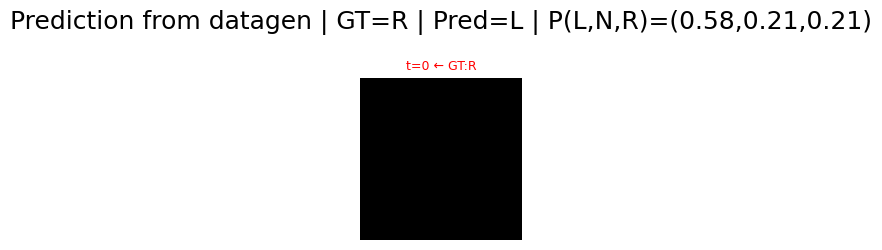

In [168]:
predict_and_visualize_from_datagen(
    model=model,
    datagen=train_gen,     # or train_gen
    max_frames_to_show=8,
)



In [60]:
import numpy as np
import tensorflow as tf
from collections import defaultdict


def compute_precision_recall(
    model,
    datagen,
    class_names,
):
    """
    Compute precision and recall for each class over the entire datagen.

    Args:
        model: trained tf.keras.Model (outputs logits)
        datagen: FrameCSVSequence
        class_names: list like ["Left", "None", "Right"]

    Returns:
        dict with per-class precision/recall/support
    """

    num_classes = len(class_names)

    # Confusion matrix counts
    tp = np.zeros(num_classes, dtype=np.int64)
    fp = np.zeros(num_classes, dtype=np.int64)
    fn = np.zeros(num_classes, dtype=np.int64)
    support = np.zeros(num_classes, dtype=np.int64)

    for i in range(len(datagen)):
        x, y_true = datagen[i]

        logits = model.predict(x, verbose=0)
        y_pred = np.argmax(tf.nn.softmax(logits, axis=-1).numpy(), axis=1)

        for c in range(num_classes):
            support[c] += np.sum(y_true == c)
            tp[c] += np.sum((y_pred == c) & (y_true == c))
            fp[c] += np.sum((y_pred == c) & (y_true != c))
            fn[c] += np.sum((y_pred != c) & (y_true == c))

    results = {}

    print("\nPrecision / Recall per class:")
    print("-" * 45)

    for c, name in enumerate(class_names):
        precision = tp[c] / (tp[c] + fp[c] + 1e-9)
        recall = tp[c] / (tp[c] + fn[c] + 1e-9)

        results[name] = {
            "precision": float(precision),
            "recall": float(recall),
            "support": int(support[c]),
        }

        print(
            f"{name:>5} | "
            f"precision: {precision:.4f} | "
            f"recall: {recall:.4f} | "
            f"support: {support[c]}"
        )

    macro_precision = np.mean([results[n]["precision"] for n in class_names])
    macro_recall = np.mean([results[n]["recall"] for n in class_names])

    print("-" * 45)
    print(f"Macro precision: {macro_precision:.4f}")
    print(f"Macro recall:    {macro_recall:.4f}")

    return results


In [61]:
class_names = ["Left", "None", "Right"]

metrics = compute_precision_recall(
    model=model,
    datagen=train_gen,
    class_names=class_names,
)



Precision / Recall per class:
---------------------------------------------
 Left | precision: 0.7486 | recall: 0.7422 | support: 11593
 None | precision: 0.0000 | recall: 0.0000 | support: 0
Right | precision: 0.6903 | recall: 0.6975 | support: 9550
---------------------------------------------
Macro precision: 0.4796
Macro recall:    0.4799
